# Customer Segmentation using K-Means Clustering


In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import os
import joblib

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("dataset/customer_segmentation.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print(df.head())

   Number  Age       Income  Spending_Score  Membership_Years  \
0       1   56  61350.84215    12372.864450                15   
1       2   46  53777.18224    11001.604230                10   
2       3   32  39460.32263     8007.385018                19   
3       4   60  66672.12210    13526.548370                12   
4       5   38  44459.08553     9059.304083                 9   

   Purchase_Frequency  Last_Purchase_Amount  
0           77.685590           6232.122440  
1           51.858351           5545.849698  
2           98.166371           4054.645293  
3           62.530976           6815.544393  
4           46.470533           4617.833484  


In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (1362, 7)


In [7]:
print("Column names:")
print(df.columns)

Column names:
Index(['Number', 'Age', 'Income', 'Spending_Score', 'Membership_Years',
       'Purchase_Frequency', 'Last_Purchase_Amount'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1362 entries, 0 to 1361
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                1362 non-null   int64  
 1   Age                   1362 non-null   int64  
 2   Income                1362 non-null   float64
 3   Spending_Score        1362 non-null   float64
 4   Membership_Years      1362 non-null   int64  
 5   Purchase_Frequency    1362 non-null   float64
 6   Last_Purchase_Amount  1362 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 74.6 KB


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Number                  0
Age                     0
Income                  0
Spending_Score          0
Membership_Years        0
Purchase_Frequency      0
Last_Purchase_Amount    0
dtype: int64


In [10]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [11]:
df = df.drop(columns=["Number"])

print("Number column removed.")

Number column removed.


In [12]:
print("Dataset after preprocessing:")
print(df.head())

Dataset after preprocessing:
   Age       Income  Spending_Score  Membership_Years  Purchase_Frequency  \
0   56  61350.84215    12372.864450                15           77.685590   
1   46  53777.18224    11001.604230                10           51.858351   
2   32  39460.32263     8007.385018                19           98.166371   
3   60  66672.12210    13526.548370                12           62.530976   
4   38  44459.08553     9059.304083                 9           46.470533   

   Last_Purchase_Amount  
0           6232.122440  
1           5545.849698  
2           4054.645293  
3           6815.544393  
4           4617.833484  


In [13]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Age                     0
Income                  0
Spending_Score          0
Membership_Years        0
Purchase_Frequency      0
Last_Purchase_Amount    0
dtype: int64


In [17]:
X = df[
    [
        "Age",
        "Income",
        "Spending_Score",
        "Membership_Years",
        "Purchase_Frequency",
        "Last_Purchase_Amount"
    ]
]

print("Features selected.")

Features selected.


In [18]:
print("Features used:")
print(X.columns)

Features used:
Index(['Age', 'Income', 'Spending_Score', 'Membership_Years',
       'Purchase_Frequency', 'Last_Purchase_Amount'],
      dtype='str')


In [19]:
print("Feature shape:", X.shape)

Feature shape: (1362, 6)


In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


In [21]:
print("Scaled feature shape:",X_scaled.shape)

Scaled feature shape: (1362, 6)


In [22]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

print("Elbow values calculated.")

Elbow values calculated.


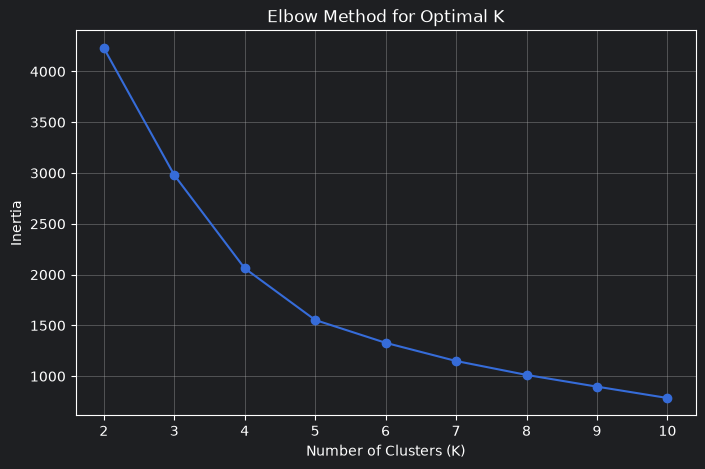

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11),inertia,marker="o")


plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal K")

plt.grid(True)

os.makedirs("images",exist_ok=True)

plt.savefig("images/elbow_method.png")

plt.show()

In [25]:
kmeans = KMeans(n_clusters=4,random_state=42, n_init=10)

print("K-Means model created.")

K-Means model created.


In [26]:
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Clustering completed.")

Clustering completed.


In [27]:
print("Number of clusters:",df["Cluster"].nunique())

Number of clusters: 4


In [28]:
print("Customers in each cluster:")

print(df["Cluster"].value_counts().sort_index())

Customers in each cluster:
Cluster
0    310
1    327
2    328
3    397
Name: count, dtype: int64


In [30]:
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Income",
        "Spending_Score",
        "Membership_Years",
        "Purchase_Frequency",
        "Last_Purchase_Amount"
    ]
].mean()

print(cluster_summary)

               Age        Income  Spending_Score  Membership_Years  \
Cluster                                                              
0        55.496774  60691.986908    12240.183821         14.677419   
1        28.036697  32954.520038     6691.607380          5.155963   
2        36.871951  41796.863878     8461.247009         14.134146   
3        51.493703  56695.220625    11442.155647          5.254408   

         Purchase_Frequency  Last_Purchase_Amount  
Cluster                                            
0                 75.248819           6169.846740  
1                 27.766625           3393.829647  
2                 72.673391           4278.731190  
3                 28.326777           5771.039162  


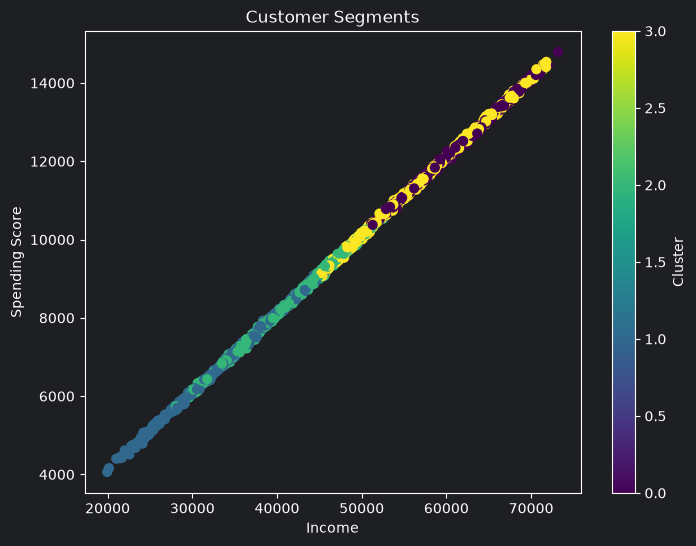

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Income"],df["Spending_Score"],c=df["Cluster"],cmap="viridis",s=40)


plt.xlabel("Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.colorbar(label="Cluster")

plt.savefig("images/customer_segments.png")

plt.show()

In [32]:
os.makedirs("model", exist_ok=True)

joblib.dump(kmeans,"model/customer_segmentation_model.pkl")

print("K-Means model saved successfully.")

K-Means model saved successfully.
